# Project Cycle 3 — Full Analysis Notebook

**Research Question:** Is the proportion of students who felt sad or hopeless different between female and male students?

This notebook contains the full workflow in one place: data loading, data cleaning, recoding, descriptive summaries, visualizations, two-proportion z-test, confidence interval, and final interpretation.

## 1. Import packages and load raw data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

ROOT = Path('..')
RAW_PATH = ROOT / 'data' / 'raw' / 'YRBS_2007.csv'
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print('Raw data shape:', df.shape)
df[['WhatIsYourSex', 'SadOrHopeless']].head()

Raw data shape: (14041, 103)


,WhatIsYourSex,SadOrHopeless
0,2.0,1.0
1,2.0,2.0
2,2.0,1.0
3,1.0,1.0
4,1.0,1.0


## 2. Select variables and check valid codes

- `WhatIsYourSex`: group variable. In this project, code 1 = Female and code 2 = Male.
- `SadOrHopeless`: response variable. Code 1 = Yes and code 2 = No.

In [2]:
selected = df[['WhatIsYourSex', 'SadOrHopeless']].copy()

print('Missing values:')
display(selected.isna().sum().to_frame('missing_count'))

print('Value counts for WhatIsYourSex:')
display(selected['WhatIsYourSex'].value_counts(dropna=False).sort_index().to_frame('count'))

print('Value counts for SadOrHopeless:')
display(selected['SadOrHopeless'].value_counts(dropna=False).sort_index().to_frame('count'))

Missing values:


,missing_count
WhatIsYourSex,13
SadOrHopeless,196


Value counts for WhatIsYourSex:


,count
WhatIsYourSex,
1.0,7036
2.0,6992
NaN,13


Value counts for SadOrHopeless:


,count
SadOrHopeless,
1.0,4153
2.0,9692
NaN,196


## 3. Clean and recode data

We keep only valid codes:

- `WhatIsYourSex` must be 1 or 2.
- `SadOrHopeless` must be 1 or 2.

Recoding rule for the binary response:

- `SadOrHopeless_binary = 1` means **Yes / success**.
- `SadOrHopeless_binary = 0` means **No / failure**.

In [3]:
cleaned = selected.dropna().copy()
cleaned = cleaned[cleaned['WhatIsYourSex'].isin([1, 2])]
cleaned = cleaned[cleaned['SadOrHopeless'].isin([1, 2])]

cleaned['Sex'] = cleaned['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})
cleaned['SadOrHopeless_binary'] = cleaned['SadOrHopeless'].map({1: 1, 2: 0})

cleaned.to_csv(PROCESSED_DIR / 'yrbs_cleaned.csv', index=False)
cleaned.to_csv(PROCESSED_DIR / 'yrbs_recoded.csv', index=False)

print('Cleaned data shape:', cleaned.shape)
cleaned.head()

Cleaned data shape: (13833, 4)


,WhatIsYourSex,SadOrHopeless,Sex,SadOrHopeless_binary
0,2.0,1.0,Male,1
1,2.0,2.0,Male,0
2,2.0,1.0,Male,1
3,1.0,1.0,Female,1
4,1.0,1.0,Female,1


## 4. Descriptive summary table

This table shows the sample size, number of students who answered Yes, number who answered No, and the Yes proportion for each group.

In [4]:
summary = (
    cleaned.groupby('Sex')['SadOrHopeless_binary']
    .agg(sample_size='count', yes_count='sum')
    .reset_index()
)
summary['no_count'] = summary['sample_size'] - summary['yes_count']
summary['proportion'] = summary['yes_count'] / summary['sample_size']
summary = summary[['Sex', 'sample_size', 'yes_count', 'no_count', 'proportion']]
summary.to_csv(TABLE_DIR / 'eda_summary_table.csv', index=False)

display(summary)

female_prop = float(summary.loc[summary['Sex']=='Female', 'proportion'].iloc[0])
male_prop = float(summary.loc[summary['Sex']=='Male', 'proportion'].iloc[0])
print(f"Female proportion = {female_prop:.4f} ({female_prop*100:.2f}%)")
print(f"Male proportion   = {male_prop:.4f} ({male_prop*100:.2f}%)")

,Sex,sample_size,yes_count,no_count,proportion
0,Female,6940,2580,4360,0.371758
1,Male,6893,1567,5326,0.227332


Female proportion = 0.3718 (37.18%)
Male proportion   = 0.2273 (22.73%)


## 5. Visualization 1 — Bar chart comparing the two groups

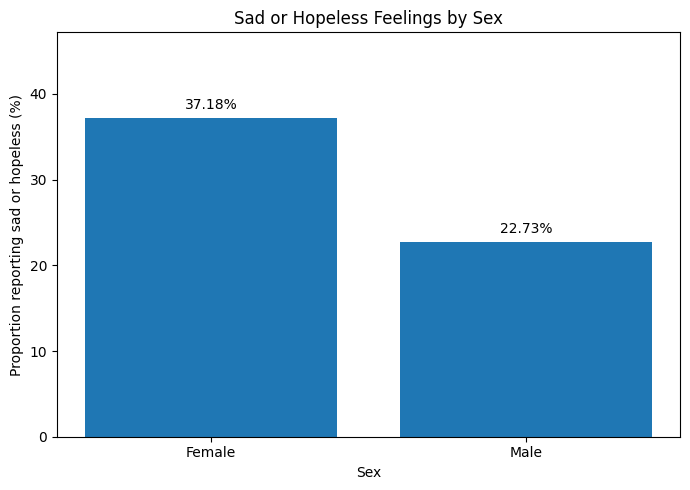

In [5]:
plot_df = summary.copy()
plot_df['percent'] = plot_df['proportion'] * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(plot_df['Sex'], plot_df['percent'])
plt.ylabel('Proportion reporting sad or hopeless (%)')
plt.xlabel('Sex')
plt.title('Sad or Hopeless Feelings by Sex')
plt.ylim(0, max(plot_df['percent']) + 10)
for bar, value in zip(bars, plot_df['percent']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.2f}%', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sad_hopeless_by_sex.png', dpi=300)
plt.show()

## 6. Two-proportion z-test and confidence interval

Because the response variable is binary, this project uses a **two-proportion z-test**.

Hypotheses:

- \(H_0: p_{Female} - p_{Male} = 0\)
- \(H_A: p_{Female} - p_{Male} 
e 0\)

Significance level: \(lpha = 0.05\).

In [6]:
n_f = int(summary.loc[summary['Sex']=='Female', 'sample_size'].iloc[0])
x_f = int(summary.loc[summary['Sex']=='Female', 'yes_count'].iloc[0])
n_m = int(summary.loc[summary['Sex']=='Male', 'sample_size'].iloc[0])
x_m = int(summary.loc[summary['Sex']=='Male', 'yes_count'].iloc[0])

p_f = x_f / n_f
p_m = x_m / n_m
diff = p_f - p_m

# Two-proportion z-test using pooled proportion for the standard error under H0
p_pool = (x_f + x_m) / (n_f + n_m)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_f + 1/n_m))
z_stat = diff / se_pool
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# 95% confidence interval using unpooled standard error
se_unpooled = np.sqrt(p_f * (1 - p_f) / n_f + p_m * (1 - p_m) / n_m)
z_crit = stats.norm.ppf(0.975)
ci_low = diff - z_crit * se_unpooled
ci_high = diff + z_crit * se_unpooled

inference = pd.DataFrame({
    'item': [
        'Female sample size', 'Female yes count', 'Female proportion',
        'Male sample size', 'Male yes count', 'Male proportion',
        'Estimated difference: Female - Male', '95% CI lower', '95% CI upper',
        'Z-statistic', 'P-value', 'Alpha', 'Decision'
    ],
    'value': [
        n_f, x_f, p_f, n_m, x_m, p_m, diff, ci_low, ci_high,
        z_stat, p_value, 0.05, 'Reject H0'
    ]
})
inference.to_csv(TABLE_DIR / 'inference_summary_table.csv', index=False)

display(inference)
print(f'Difference = {diff:.4f} ({diff*100:.2f} percentage points)')
print(f'95% CI = [{ci_low:.4f}, {ci_high:.4f}] = [{ci_low*100:.2f}%, {ci_high*100:.2f}%]')
print(f'z = {z_stat:.4f}')
print(f'p-value = {p_value:.3e}')
print('Decision: Reject H0 because p-value < 0.05')

,item,value
0,Female sample size,6940
1,Female yes count,2580
2,Female proportion,0.371758
3,Male sample size,6893
4,Male yes count,1567
5,Male proportion,0.227332
6,Estimated difference: Female - Male,0.144426
7,95% CI lower,0.129354
8,95% CI upper,0.159498
9,Z-statistic,18.537354


Difference = 0.1444 (14.44 percentage points)
95% CI = [0.1294, 0.1595] = [12.94%, 15.95%]
z = 18.5374
p-value = 0.000e+00
Decision: Reject H0 because p-value < 0.05


## 7. Visualization 2 — Confidence interval for the difference

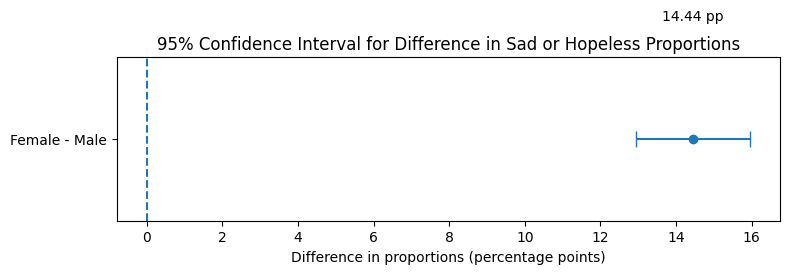

In [7]:
plt.figure(figsize=(8, 3))
plt.errorbar(diff * 100, 1, xerr=[[ (diff-ci_low)*100 ], [ (ci_high-diff)*100 ]], fmt='o', capsize=6)
plt.axvline(0, linestyle='--')
plt.yticks([1], ['Female - Male'])
plt.xlabel('Difference in proportions (percentage points)')
plt.title('95% Confidence Interval for Difference in Sad or Hopeless Proportions')
plt.text(diff*100, 1.08, f'{diff*100:.2f} pp', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confidence_interval_difference.png', dpi=300)
plt.show()

## 8. Final interpretation

Female students had a higher proportion of reporting sad or hopeless feelings than male students.

The estimated difference was about **14.44 percentage points**, with a 95% confidence interval of about **[12.94%, 15.95%]**. The two-proportion z-test gave a very small p-value, so we reject the null hypothesis at \(lpha = 0.05\).

**Conclusion:** In this dataset, the proportion of students who felt sad or hopeless was significantly different between female and male students, with female students reporting a higher proportion.

**Important limitation:** This is observational survey data, so the result shows an association, not causation.